# Load libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load the data
df = pd.read_csv('../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape


(7043, 21)

## BASIC INFO

In [5]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [6]:
df.shape

(7043, 21)

In [7]:
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [8]:
print("Missing value")
df.isnull().sum()

Missing value


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
print("Target value Distribution")
print(df['Churn'].value_counts())

Target value Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [10]:
print(f"Churn Rate[Yes]:  {df['Churn'].value_counts(normalize=True)["Yes"]*100:.2f}")
print(f"Churn Rate[No]:  {df['Churn'].value_counts(normalize=True)["No"]*100:.2f}")

Churn Rate[Yes]:  26.54
Churn Rate[No]:  73.46


## Analyse Numberic Features

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [12]:
df[numerical_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Visualise Target Variable

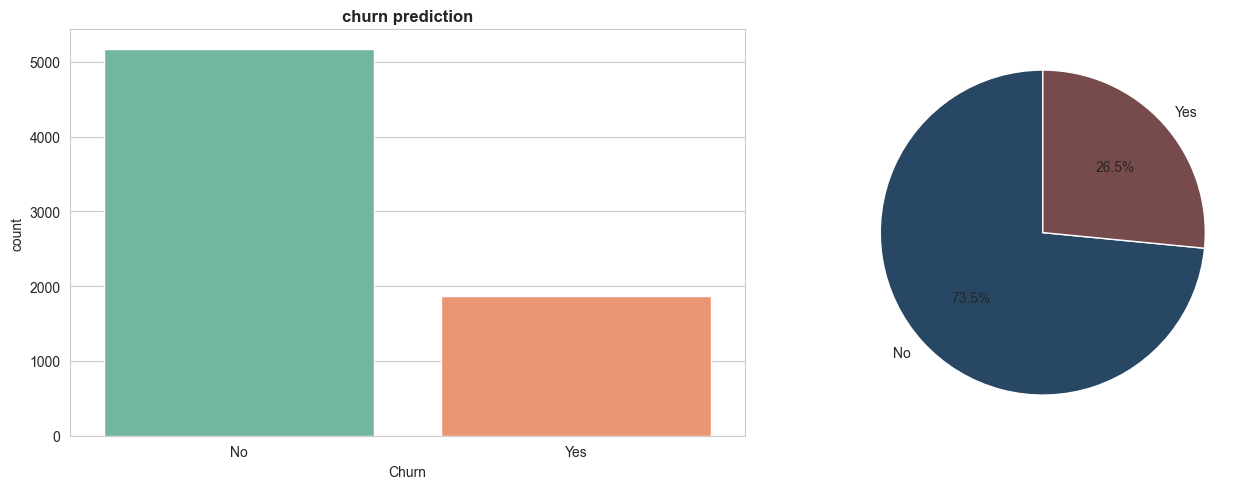

Saved: reports/churn_distribution.png


In [13]:
fig,ax = plt.subplots(1,2, figsize=(14,5))
sns.countplot(data = df, x = 'Churn', ax=ax[0], palette='Set2')
ax[0].set_title('churn Distribution', fontweight='bold')
churn_count = df['Churn'].value_counts()
ax[1].pie(churn_count,
            labels = churn_count.index,
            autopct = '%1.1f%%',
            startangle= 90,
            colors=["#284765", "#774B4B"])
ax[0].set_title('churn prediction', fontweight='bold')

plt.tight_layout()
#save
plt.savefig('../reports/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: reports/churn_distribution.png")

## Numerical Features v/s Churn

<Axes: xlabel='Churn', ylabel='tenure'>

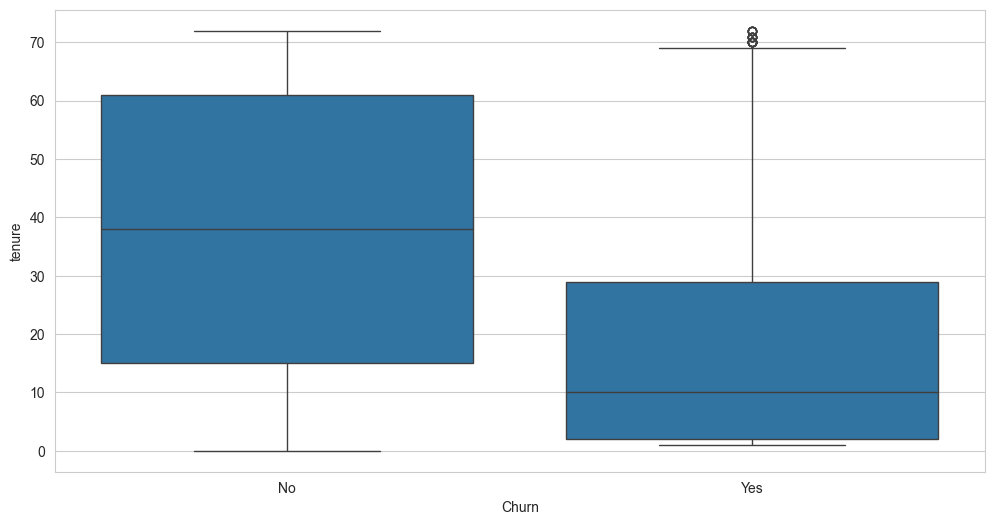

In [14]:
sns.boxplot(data=df, x = 'Churn', y = 'tenure')

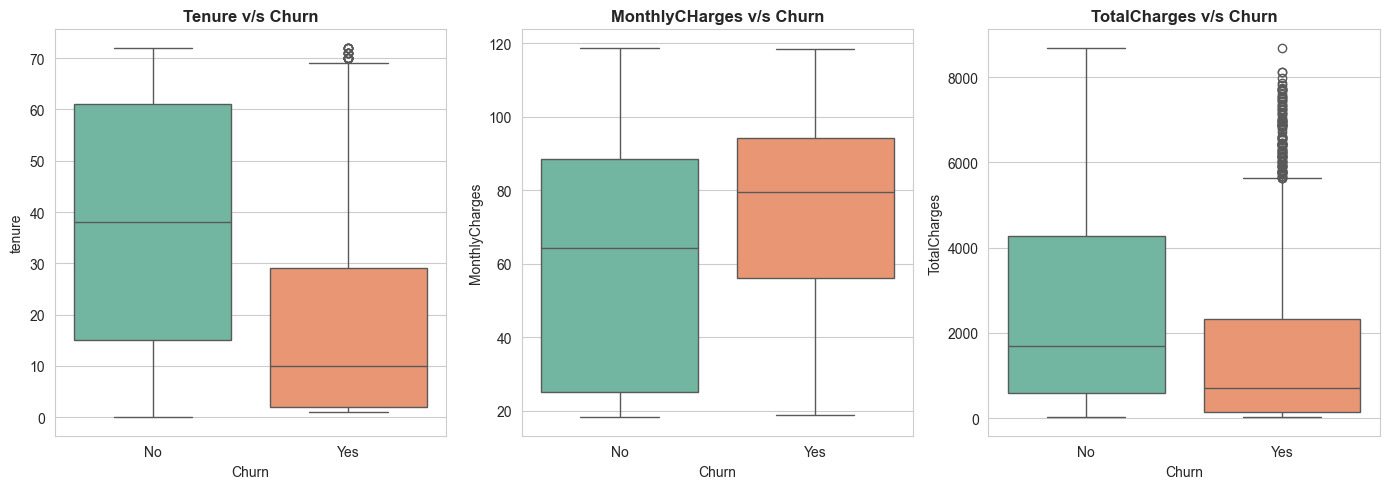

Saved: reports/Numerical_Analysis.png


In [15]:
fig,ax = plt.subplots(1,3, figsize=(14,5))

# TODO: first Graph - Tenure
sns.boxplot(data = df, x = 'Churn', y = 'tenure', ax=ax[0], palette='Set2')
ax[0].set_title('Tenure v/s Churn', fontweight='bold')

#TODO: second - monthlyCharge
sns.boxplot(data = df, x = 'Churn', y = 'MonthlyCharges', ax=ax[1], palette='Set2')
ax[1].set_title('MonthlyCHarges v/s Churn', fontweight='bold')
#TODO: Third - TotalCharge

sns.boxplot(data = df, x = 'Churn', y = 'TotalCharges', ax=ax[2], palette='Set2')
ax[2].set_title('TotalCharges v/s Churn', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/Numerical_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: reports/Numerical_Analysis.png")

## Analyse Categorical Features

In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [17]:
categorical_cols.remove("customerID")
categorical_cols.remove("Churn")
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [18]:
print(f"categorical columns: ({len(categorical_cols)}): {categorical_cols}")

categorical columns: (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


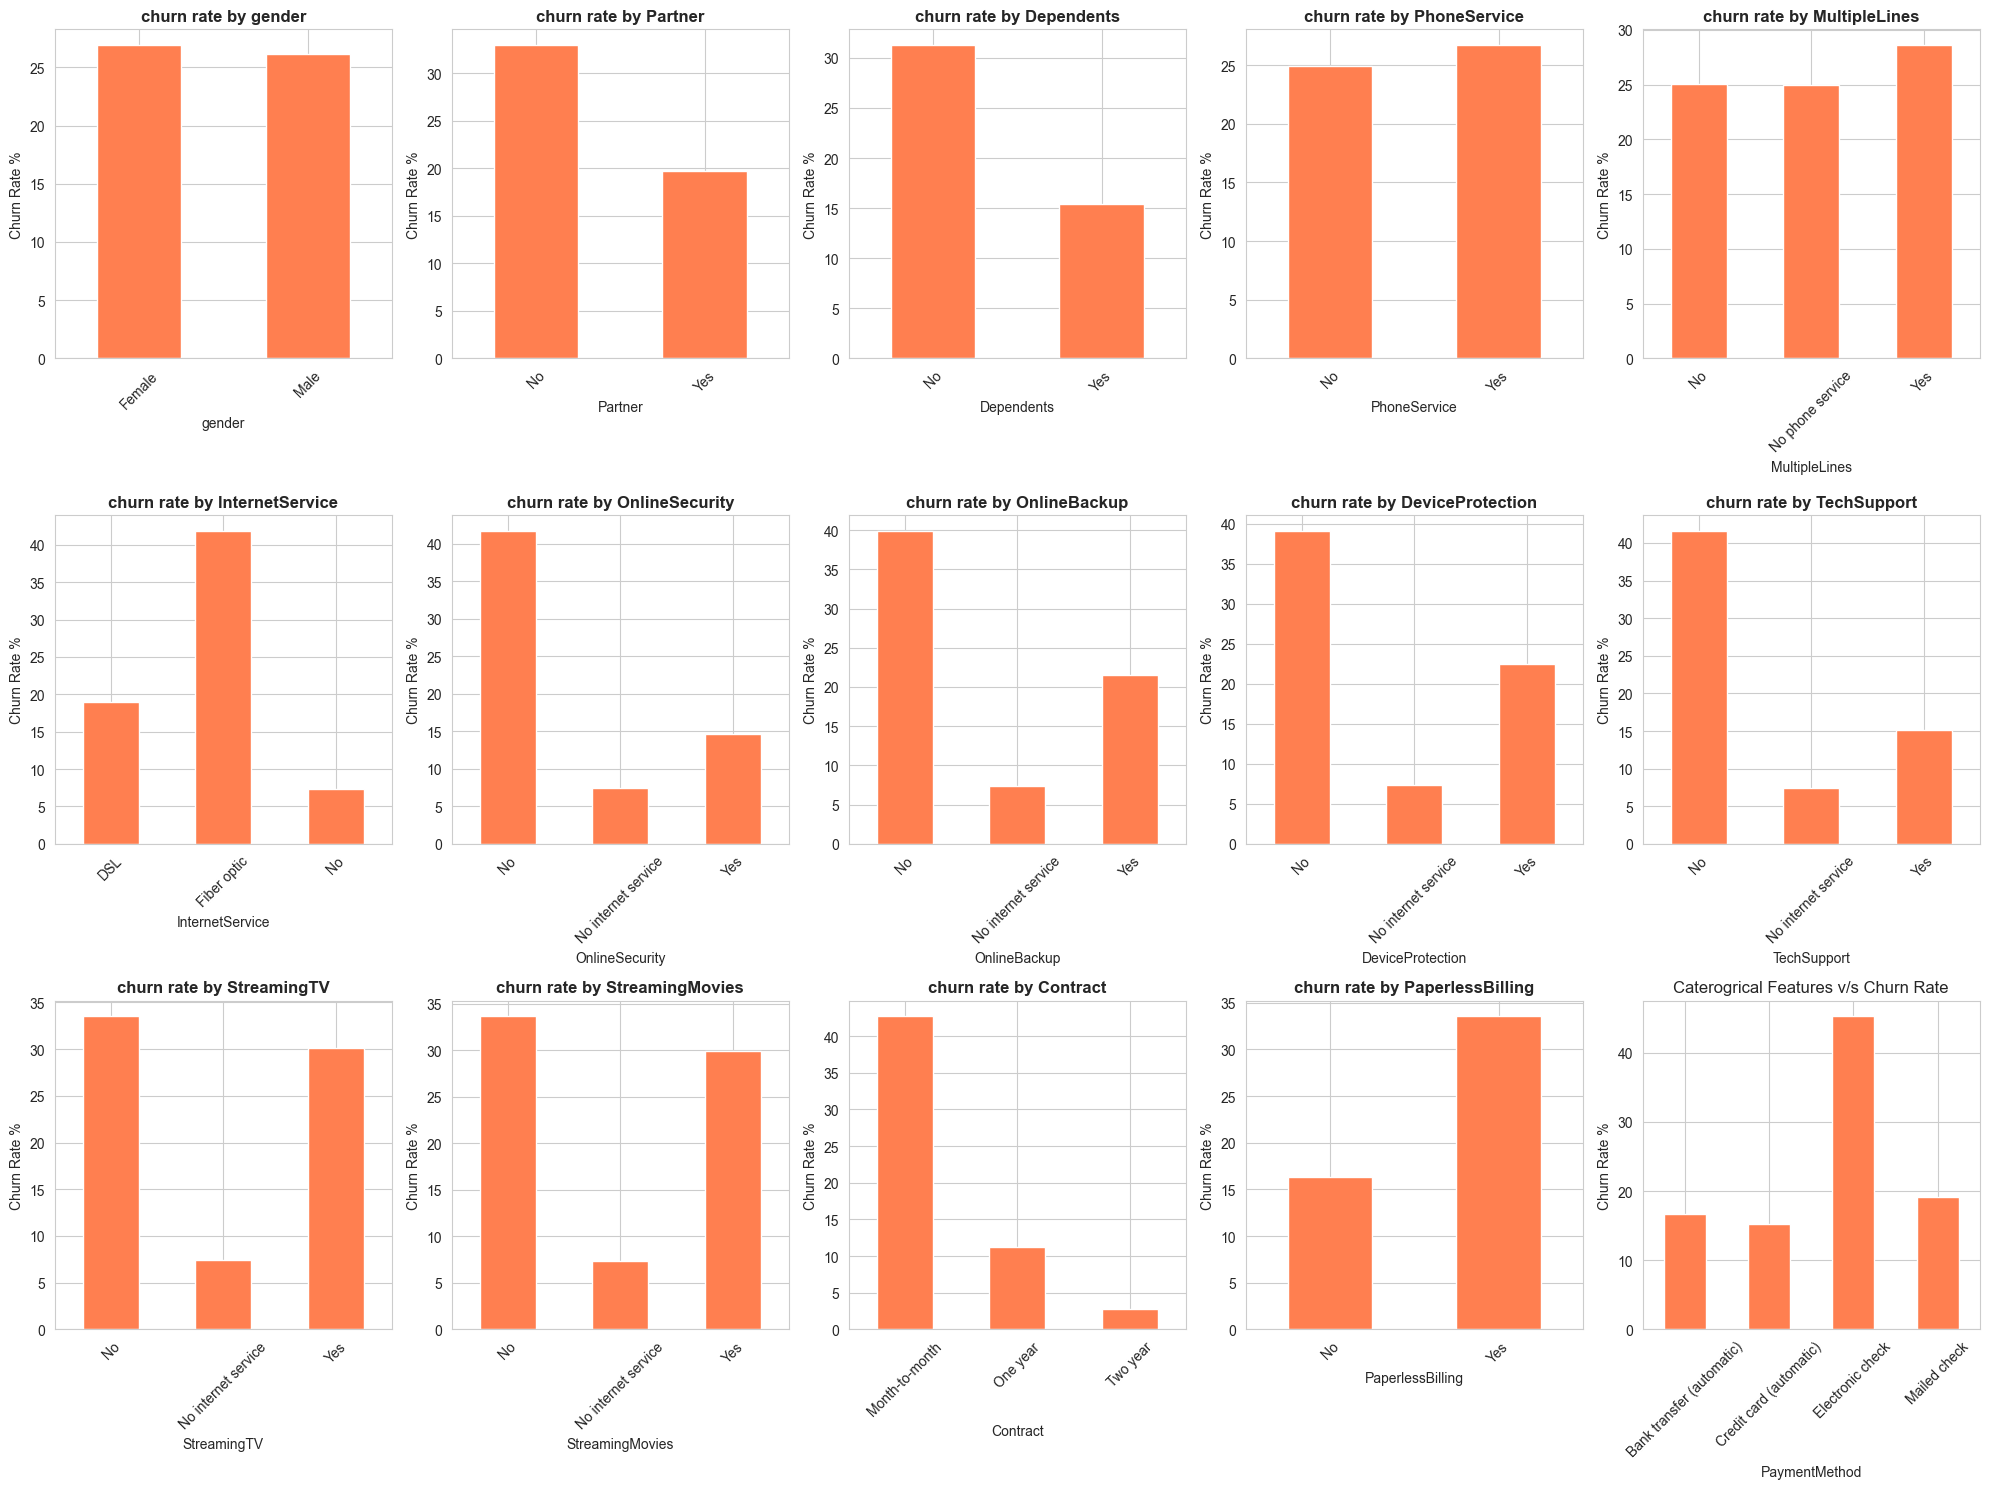

Saved: reports/categorical_Analysis.png


In [19]:
fig, ax = plt.subplots(3,5, figsize = (20,15))
ax = ax.flatten()
for idx, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').sum()/len(x)*100)
    churn_rate.plot(kind='bar', ax = ax[idx], color = 'coral')
    ax[idx].set_title(f'churn rate by {col}', fontweight='bold')
    ax[idx].set_ylabel("Churn Rate %")
    ax[idx].set_xlabel(col)
    ax[idx].tick_params(axis='x', rotation=45)


plt.title("Caterogrical Features v/s Churn Rate")
plt.tight_layout()
plt.savefig('../reports/categorical_analysis.png', dpi=300, bbox_inches = 'tight')
plt.show()
print(f"Saved: reports/categorical_Analysis.png")

In [20]:
df.groupby('DeviceProtection')['Churn'].apply(lambda x: (x=='Yes').sum()/len(x)*100)

DeviceProtection
No                     39.127625
No internet service     7.404980
Yes                    22.502064
Name: Churn, dtype: float64

In [21]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

In [22]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df_corr[numerical_features].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.352229,0.193356,-0.199484,1.000000


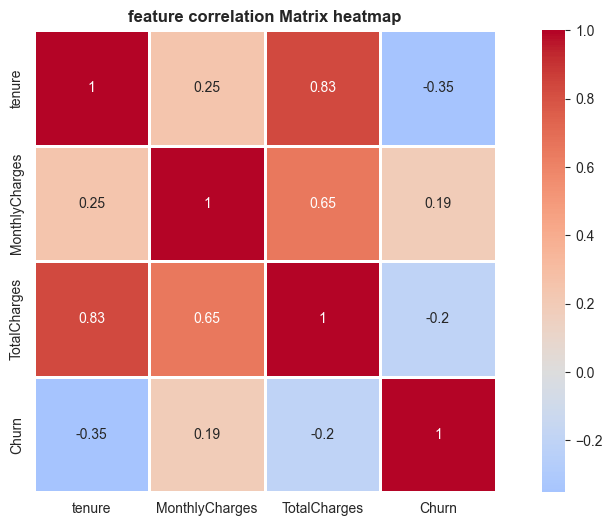

Saved: reports/correlation_heatmap_Analysis.png


In [23]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title("feature correlation Matrix heatmap", fontweight='bold')
plt.savefig('../reports/correclation_heatmap.png', dpi=300, bbox_inches = 'tight')
plt.show()
print(f"Saved: reports/correlation_heatmap_Analysis.png")

NOTE: A multicolinearity between 'tenure' and 'TotalCharges'

In [24]:
print("="*60)
print("KEY INSIGHT FROM EDA")
print("="*60)

print(f"\n1. Dataset size: {df.shape[0]}, cuatomers, {df.shape[1]} features")
print(f"2. Churn rate: {(df['Churn']=='Yes').sum()/len(df)*100:.2f}%")
print(f"3. missing values: {df.isnull().sum().sum()} total")

avg_tenure_churn = df[df['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_No_churn = df[df['Churn'] == 'No']['tenure'].mean()

print(f"4. Average Tenure (churned): {avg_tenure_churn: .1f} months")
print(f"5. Average Tenure (Not churned): {avg_tenure_No_churn: .1f} months")

avg_monthly_churn = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_monthly_No_churn = df[df['Churn'] == 'No']['MonthlyCharges'].mean()

print(f"6. Average Montly Charges (churend): ${avg_monthly_churn: .1f}")
print(f"7. Average Montly Charges (Not churend): ${avg_monthly_No_churn: .1f}\n")


print("="*60)
print("A holistic analysis reveals that short-term, high-cost, digital\n service (fiber Optic/Electronic checks) are the primary churn\n drivers, while long-term and value-added security\n services are the strongest indicators of customer loyalty.")
print("="*60)


print("="*60)
print("EDA COMPLETED")
print("="*60)

KEY INSIGHT FROM EDA

1. Dataset size: 7043, cuatomers, 21 features
2. Churn rate: 26.54%
3. missing values: 11 total
4. Average Tenure (churned):  18.0 months
5. Average Tenure (Not churned):  37.6 months
6. Average Montly Charges (churend): $ 74.4
7. Average Montly Charges (Not churend): $ 61.3

A holistic analysis reveals that short-term, high-cost, digital
 service (fiber Optic/Electronic checks) are the primary churn
 drivers, while long-term and value-added security
 services are the strongest indicators of customer loyalty.
EDA COMPLETED
